In [1]:
import os
os.environ["PYSPARK_SUBMIT_ARGS"] = "--driver-memory 4g pyspark-shell"

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import seaborn as sns

# Học máy phân tán với Spark MLlib - Phân cụm chuyến đi taxi

Đọc dữ liệu đã làm sạch `yellow_taxi_cleaned` (từ `data_preprocessing`), phân cụm chuyến đi bằng
**KMeans** và **BisectingKMeans**, dùng **Silhouette** để chọn thuật toán tốt hơn.

**Quy mô huấn luyện:** lấy mẫu ngẫu nhiên **~20%** (khoảng 700.000 chuyến) làm tập huấn luyện -
đủ lớn, đại diện, lại nhẹ và nhanh. Bước dò chọn số cụm k quét trên mẫu nhỏ hơn (~90.000) cho nhanh.

**Trước khi chạy:** đã chạy xong `EDA` và `data_preprocessing` (có `yellow_taxi_cleaned` trong HDFS)
và HDFS đang chạy (`start-dfs.cmd`).

## 1. Xác định bài toán

- **Vấn đề:** Trong hàng triệu chuyến đi, tồn tại những "kiểu" chuyến nào khác biệt? Nhận diện các
  phân khúc chuyến đi giúp doanh nghiệp điều phối xe, định giá và chăm sóc khách hàng tốt hơn.
- **Loại bài toán:** Học **không giám sát** (Unsupervised) - **phân cụm** (Clustering). **Không có
  biến mục tiêu (target)**; mục tiêu là tự động gom các chuyến đi tương đồng vào cùng một nhóm.
- **Đặc trưng (features):** `trip_distance`, `trip_duration_minutes`, `fare_amount`, `tip_amount`,
  `avg_speed_mph`.
- **Thuật toán:** **KMeans** và **BisectingKMeans** (phân cụm phân cấp kiểu chia đôi - thuật toán
  phân cụm phân cấp có sẵn trong Spark MLlib). Với mỗi thuật toán thử k = 2..8, tính **Silhouette**,
  rồi **chọn thuật toán cho Silhouette cao hơn**.
- **Chuẩn hóa:** các đặc trưng khác đơn vị (dặm, phút, đô-la) nên cần **StandardScaler** trước khi
  phân cụm, vì KMeans dựa trên khoảng cách Euclid.

## 2. Đọc dữ liệu, lọc ngoại lai, lấy mẫu 20% và chuẩn hóa

KMeans rất nhạy với giá trị ngoại lai (chuyến cực dài, tốc độ phi lý do lỗi GPS...). Vì bản
`yellow_taxi_cleaned` chưa cắt ngoại lai, ở đây ta lọc thêm bằng ngưỡng hợp lý trước khi phân cụm.

In [2]:
spark = (
    SparkSession.builder
    #.master("spark://100.77.205.48:7077")
    .appName("NYC Taxi - MLlib Clustering")
    .config("spark.sql.session.timeZone", "UTC")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

df = spark.read.parquet("hdfs://localhost:9000/output/yellow_taxi_cleaned")
print(f"Tong so chuyen (cleaned): {df.count():,}")

Tong so chuyen (cleaned): 3,502,694


In [3]:
# Loc ngoai lai phuc vu phan cum (giu lai chuyen hop ly, ke ca chuyen dai/san bay)
df = df.filter(
    (col("trip_distance") <= 100) &
    (col("trip_duration_minutes") <= 240) &
    (col("avg_speed_mph") <= 80) &
    (col("total_amount") <= 1000)
)

feature_cols = ["trip_distance", "trip_duration_minutes", "fare_amount", "tip_amount", "avg_speed_mph"]
base = df.select(*feature_cols, "is_airport_trip").na.drop()
print(f"So chuyen sau khi loc ngoai lai: {base.count():,}")

# === LAY MAU 20% LAM TAP HUAN LUYEN ===
data20 = base.sample(withReplacement=False, fraction=0.2, seed=42).cache()
print(f"So chuyen trong mau 20% (tap huan luyen): {data20.count():,}")

So chuyen sau khi loc ngoai lai: 3,500,505
So chuyen trong mau 20% (tap huan luyen): 701,020


In [4]:
# Gom dac trung thanh vector roi chuan hoa (fit tren chinh mau 20%)
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
assembled = assembler.transform(data20)

scaler_model = StandardScaler(inputCol="features_raw", outputCol="features",
                              withMean=True, withStd=True).fit(assembled)
scaled = scaler_model.transform(assembled).cache()
scaled.count()

# Mau nho hon (~90k) chi de DO CHON so cum k cho nhanh
sweep_sample = scaled.sample(withReplacement=False, fraction=0.13, seed=42).cache()
print(f"So chuyen trong mau do k: {sweep_sample.count():,}")

So chuyen trong mau do k: 91,192


## 3. Chọn số cụm k và so sánh KMeans vs BisectingKMeans

Với mỗi k, huấn luyện cả hai thuật toán và tính Silhouette (càng gần 1 càng tốt); ghi thêm WSSSE
của KMeans để vẽ biểu đồ khuỷu tay (elbow).

In [5]:
evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="prediction",
                                metricName="silhouette", distanceMeasure="squaredEuclidean")

ks = list(range(2, 9))
km_sil, bk_sil, km_wssse = [], [], []

for k in ks:
    km = KMeans(featuresCol="features", k=k, seed=42).fit(sweep_sample)
    km_sil.append(evaluator.evaluate(km.transform(sweep_sample)))
    km_wssse.append(km.summary.trainingCost)

    bk = BisectingKMeans(featuresCol="features", k=k, seed=42).fit(sweep_sample)
    bk_sil.append(evaluator.evaluate(bk.transform(sweep_sample)))
    print(f"k={k}:  KMeans silhouette={km_sil[-1]:.4f} | BisectingKMeans silhouette={bk_sil[-1]:.4f}")

k=2:  KMeans silhouette=0.7857 | BisectingKMeans silhouette=0.7856
k=3:  KMeans silhouette=0.6263 | BisectingKMeans silhouette=0.4391
k=4:  KMeans silhouette=0.5741 | BisectingKMeans silhouette=0.4610
k=5:  KMeans silhouette=0.5007 | BisectingKMeans silhouette=0.2290
k=6:  KMeans silhouette=0.4726 | BisectingKMeans silhouette=0.2579
k=7:  KMeans silhouette=0.4602 | BisectingKMeans silhouette=0.2766
k=8:  KMeans silhouette=0.4676 | BisectingKMeans silhouette=0.2713


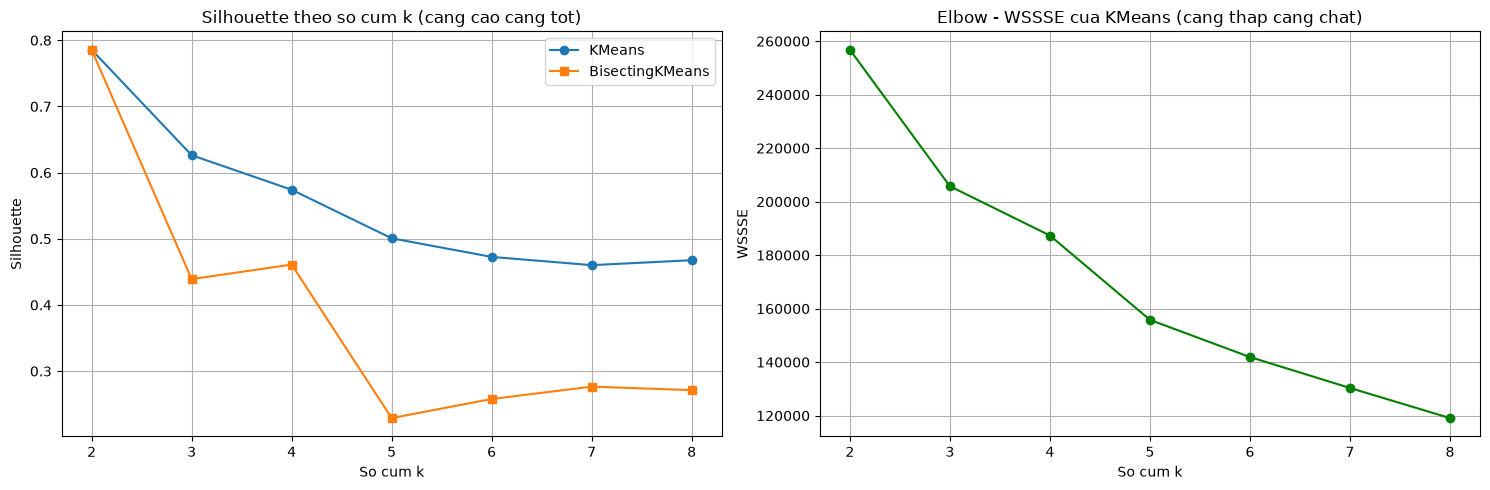

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(ks, km_sil, marker="o", label="KMeans")
axes[0].plot(ks, bk_sil, marker="s", label="BisectingKMeans")
axes[0].set_title("Silhouette theo so cum k (cang cao cang tot)")
axes[0].set_xlabel("So cum k"); axes[0].set_ylabel("Silhouette"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(ks, km_wssse, marker="o", color="green")
axes[1].set_title("Elbow - WSSSE cua KMeans (cang thap cang chat)")
axes[1].set_xlabel("So cum k"); axes[1].set_ylabel("WSSSE"); axes[1].grid(True)
plt.tight_layout(); plt.show()

**Nhận xét:** KMeans cho Silhouette **cao hơn** BisectingKMeans ở hầu hết các k → chọn **KMeans**.
Silhouette cao nhất ở k=2 (hai nhóm rất tách biệt), nhưng để có phân khúc chi tiết và hữu ích hơn
cho kinh doanh, nhóm chọn **k = 4** (Silhouette vẫn ở mức tách cụm tốt).

## 4. Huấn luyện mô hình cuối: KMeans với k = 4 (trên mẫu 20%)

In [7]:
K = 4
final_model = KMeans(featuresCol="features", k=K, seed=42).fit(scaled)
result = final_model.transform(scaled).cache()

final_sil = evaluator.evaluate(final_model.transform(sweep_sample))
print(f"Silhouette cua mo hinh KMeans k={K}: {final_sil:.4f}")
print("So chuyen moi cum:")
result.groupBy("prediction").count().orderBy("prediction").show()

Silhouette cua mo hinh KMeans k=4: 0.5914
So chuyen moi cum:
+----------+------+
|prediction| count|
+----------+------+
|         0|145737|
|         1| 35563|
|         2|494052|
|         3| 25668|
+----------+------+



In [8]:
# Chan dung tung cum: trung binh cac dac trung GOC + ty le chuyen san bay
profile = (result.groupBy("prediction")
    .agg(count("*").alias("so_chuyen"),
         round(avg("trip_distance"), 2).alias("quang_duong_mi"),
         round(avg("trip_duration_minutes"), 1).alias("thoi_luong_phut"),
         round(avg("fare_amount"), 2).alias("gia_cuoc"),
         round(avg("tip_amount"), 2).alias("tien_tip"),
         round(avg("avg_speed_mph"), 1).alias("toc_do_mph"),
         round(avg("is_airport_trip") * 100, 1).alias("pct_san_bay"))
    .orderBy("prediction"))
profile.show(truncate=False)

+----------+---------+--------------+---------------+--------+--------+----------+-----------+
|prediction|so_chuyen|quang_duong_mi|thoi_luong_phut|gia_cuoc|tien_tip|toc_do_mph|pct_san_bay|
+----------+---------+--------------+---------------+--------+--------+----------+-----------+
|0         |145737   |5.64          |23.9           |31.35   |1.98    |15.7      |9.8        |
|1         |35563    |14.2          |38.3           |61.96   |14.65   |24.0      |87.2       |
|2         |494052   |1.52          |11.5           |13.17   |2.12    |8.5       |0.2        |
|3         |25668    |14.44         |57.9           |58.9    |0.53    |17.4      |30.3       |
+----------+---------+--------------+---------------+--------+--------+----------+-----------+



## 5. Diễn giải kết quả - đặt tên các phân khúc

Dựa trên chân dung trung bình của từng cụm (bảng trên), đặt tên 4 phân khúc:

- **Nội đô ngắn** (chiếm đa số): quãng đường rất ngắn (~1.5 dặm), giá cước thấp (~$13), hầu như
  không phải chuyến sân bay - các chuyến đi lại trong phố.
- **Trung bình**: quãng đường ~5-6 dặm, giá cước ~$31, ít chuyến sân bay.
- **Sân bay - tip cao**: quãng đường dài (~14 dặm), giá cước cao (~$62), **tip rất cao (~$14)**,
  đa số là chuyến sân bay - khách trả thẻ, tip hậu hĩnh.
- **Chuyến dài - tắc đường, tip thấp**: quãng đường dài nhưng **thời lượng lâu hơn hẳn (~57 phút)**,
  tốc độ thấp (kẹt xe), **tip gần như bằng 0** - nhiều khả năng trả tiền mặt nên không ghi nhận tip.

Kết quả phân cụm **củng cố** phát hiện từ Spark SQL: có ranh giới rõ giữa chuyến nội đô ngắn/rẻ và
chuyến dài/đắt (điển hình là sân bay), đồng thời làm lộ thêm khác biệt về hành vi tip giữa nhóm trả
thẻ và trả tiền mặt.

## 6. Trực quan hóa các cụm

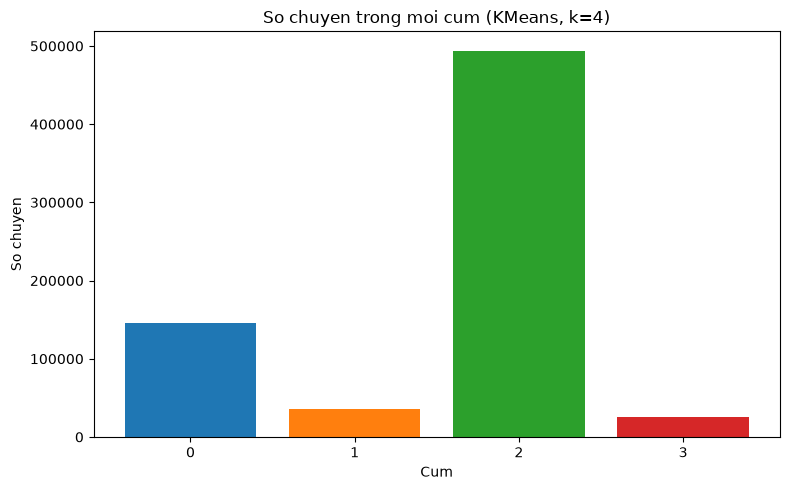

In [9]:
pdf_cnt = result.groupBy("prediction").count().orderBy("prediction").toPandas()
plt.figure(figsize=(8, 5))
plt.bar(pdf_cnt["prediction"].astype(str), pdf_cnt["count"], color=sns.color_palette("tab10", K))
plt.title(f"So chuyen trong moi cum (KMeans, k={K})")
plt.xlabel("Cum"); plt.ylabel("So chuyen")
plt.tight_layout(); plt.show()

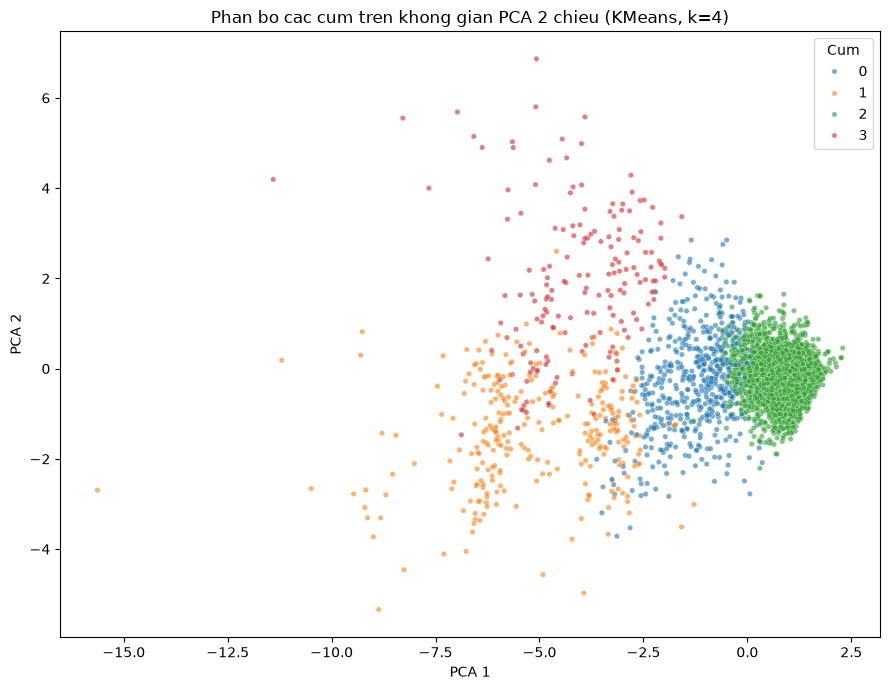

In [10]:
# Giam chieu ve 2D bang PCA de ve scatter (lay mau ~4000 diem cho de nhin)
pca = PCA(k=2, inputCol="features", outputCol="pca2").fit(result)
viz = (pca.transform(result).select("pca2", "prediction")
       .sample(False, 0.02, seed=42).limit(4000).toPandas())
viz["x"] = viz["pca2"].apply(lambda v: float(v[0]))
viz["y"] = viz["pca2"].apply(lambda v: float(v[1]))

plt.figure(figsize=(9, 7))
sns.scatterplot(data=viz, x="x", y="y", hue="prediction", palette="tab10", s=15, alpha=0.6)
plt.title(f"Phan bo cac cum tren khong gian PCA 2 chieu (KMeans, k={K})")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2"); plt.legend(title="Cum")
plt.tight_layout(); plt.show()

## 7. Kết luận

- Đã phân cụm chuyến đi bằng Spark MLlib với **KMeans** và **BisectingKMeans**, đánh giá bằng
  **Silhouette**, huấn luyện trên **mẫu 20%** (~700.000 chuyến).
- **KMeans cho Silhouette cao hơn** → chọn làm mô hình cuối; với **k = 4** thu được 4 phân khúc rõ
  ràng, có ý nghĩa kinh doanh (nội đô ngắn, trung bình, sân bay tip cao, chuyến dài tắc đường tip thấp).
- Kết quả nhất quán với phân tích Spark SQL; có thể ứng dụng vào điều phối xe, định giá và phân khúc
  khách hàng.

In [11]:
spark.stop()